# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, load_glass_data, load_breast_cancer_data, scale_features, plot_projection

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The ZOO dataset

#### Data preparation

In [3]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

#### Train FreeVIZ

In [4]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.2890625
step: 3 loss: 20747.513671875
step: 4 loss: 19672.515625
step: 5 loss: 12327.8173828125
step: 6 loss: 11816.6328125
step: 7 loss: 11520.2734375
step: 8 loss: 11745.88671875
step: 9 loss: 12014.47265625
step: 10 loss: 12151.3095703125
step: 11 loss: 12283.1416015625
step: 12 loss: 12389.8935546875


#### Train SPCA Classification

In [5]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = 0.01
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 3.1496, classifier loss = 1.8512
Step 10: loss = 2.4884, classifier loss = 1.1862
Step 20: loss = 2.2209, classifier loss = 0.9160
Step 30: loss = 2.0954, classifier loss = 0.7894
Step 40: loss = 2.0196, classifier loss = 0.7127
Step 50: loss = 1.9651, classifier loss = 0.6575
Step 60: loss = 1.9219, classifier loss = 0.6136
Step 70: loss = 1.8859, classifier loss = 0.5769
Step 80: loss = 1.8549, classifier loss = 0.5455
Step 90: loss = 1.8277, classifier loss = 0.5176
Step 100: loss = 1.8034, classifier loss = 0.4930
Step 110: loss = 1.7813, classifier loss = 0.4702
Step 120: loss = 1.7607, classifier loss = 0.4486
Step 130: loss = 1.7412, classifier loss = 0.4270
Step 140: loss = 1.7227, classifier loss = 0.4054
Step 150: loss = 1.7054, classifier loss = 0.3842
Step 160: loss = 1.6894, classifier loss = 0.3640
Step 170: loss = 1.6747, classifier loss = 0.3451
Step 180: loss = 1.6613, classifier loss = 0.3277
Step 190: loss = 1.6490, classifier loss = 0.3119
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


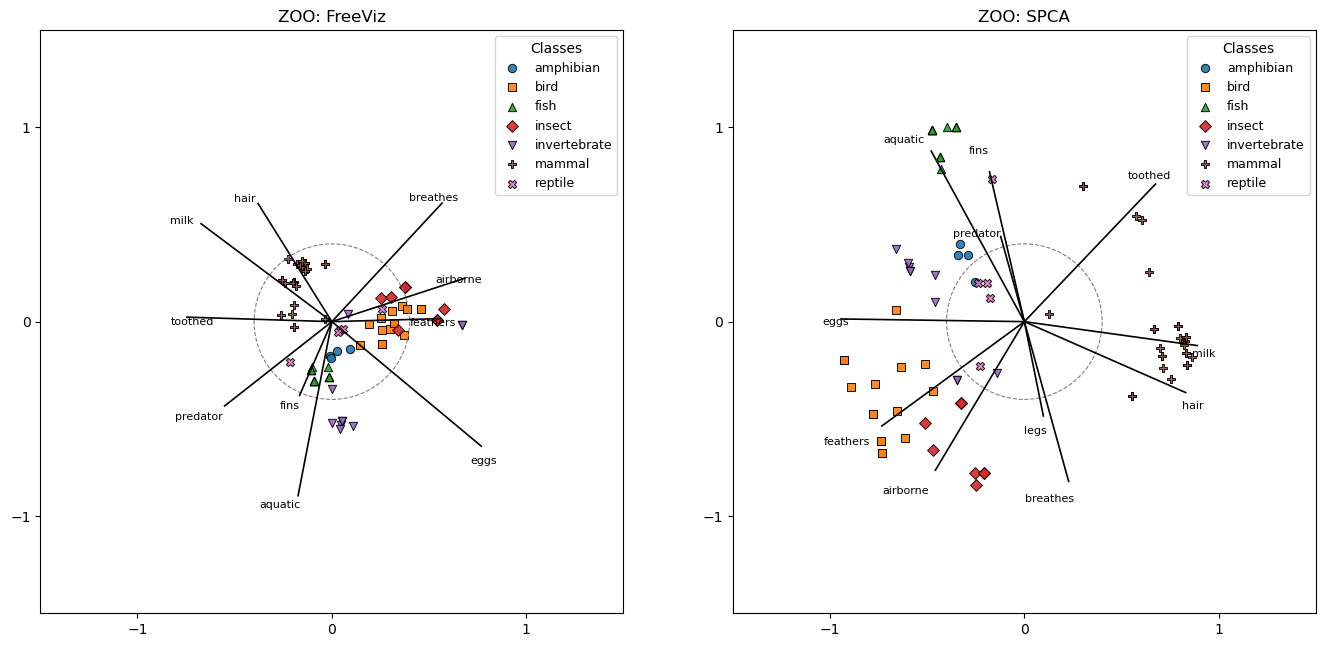

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [7]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

#### Train FreeVIZ

In [8]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156914.0
step: 2 loss: 2270743.25
step: 3 loss: 2286272.25
step: 4 loss: 2316779.0
step: 5 loss: 2224857.0
step: 6 loss: 2199510.5
step: 7 loss: 2204252.25
step: 8 loss: 2171202.75
step: 9 loss: 2179453.0
step: 10 loss: 2232810.5
step: 11 loss: 2246996.75
step: 12 loss: 2225775.5
step: 13 loss: 1789912.375
step: 14 loss: 1899330.875
step: 15 loss: 1897699.375
step: 16 loss: 1873360.625
step: 17 loss: 1852525.75
step: 18 loss: 1843441.375
step: 19 loss: 1813697.125
step: 20 loss: 1774853.375
step: 21 loss: 1774039.25
step: 22 loss: 1739939.0
step: 23 loss: 1742685.5
step: 24 loss: 1718019.125
step: 25 loss: 1694837.5
step: 26 loss: 1659945.375
step: 27 loss: 1668269.0
step: 28 loss: 1568229.25
step: 29 loss: 1531444.75
step: 30 loss: 1495577.5
step: 31 loss: 1456927.875
step: 32 loss: 1435309.375
step: 33 loss: 2522999.5
step: 34 loss: 1865200.5
step: 35 loss: 1851267.0
step: 36 loss: 1799286.625
step: 37 loss: 1857845.125
step: 38 loss: 1671501.625
step: 39 loss: 167911

#### Train SPCA Classification

In [9]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=0.01, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 77.6981, classifier loss = 0.6393
Step 10: loss = 77.4389, classifier loss = 0.3790
Step 20: loss = 77.3743, classifier loss = 0.3138
Step 30: loss = 77.3549, classifier loss = 0.2941
Step 40: loss = 77.3533, classifier loss = 0.2924
Step 50: loss = 77.3523, classifier loss = 0.2912
Step 60: loss = 77.3514, classifier loss = 0.2903
Step 70: loss = 77.3507, classifier loss = 0.2895
Step 80: loss = 77.3500, classifier loss = 0.2887
Step 90: loss = 77.3494, classifier loss = 0.2881
Step 100: loss = 77.3489, classifier loss = 0.2876
Step 110: loss = 77.3485, classifier loss = 0.2871
Step 120: loss = 77.3480, classifier loss = 0.2866
Step 130: loss = 77.3477, classifier loss = 0.2862
Step 140: loss = 77.3474, classifier loss = 0.2859
Step 150: loss = 77.3471, classifier loss = 0.2856
Step 160: loss = 77.3469, classifier loss = 0.2854
Step 170: loss = 77.3467, classifier loss = 0.2851
Step 180: loss = 77.3465, classifier loss = 0.2849
Step 190: loss = 77.3464, classifier loss 

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


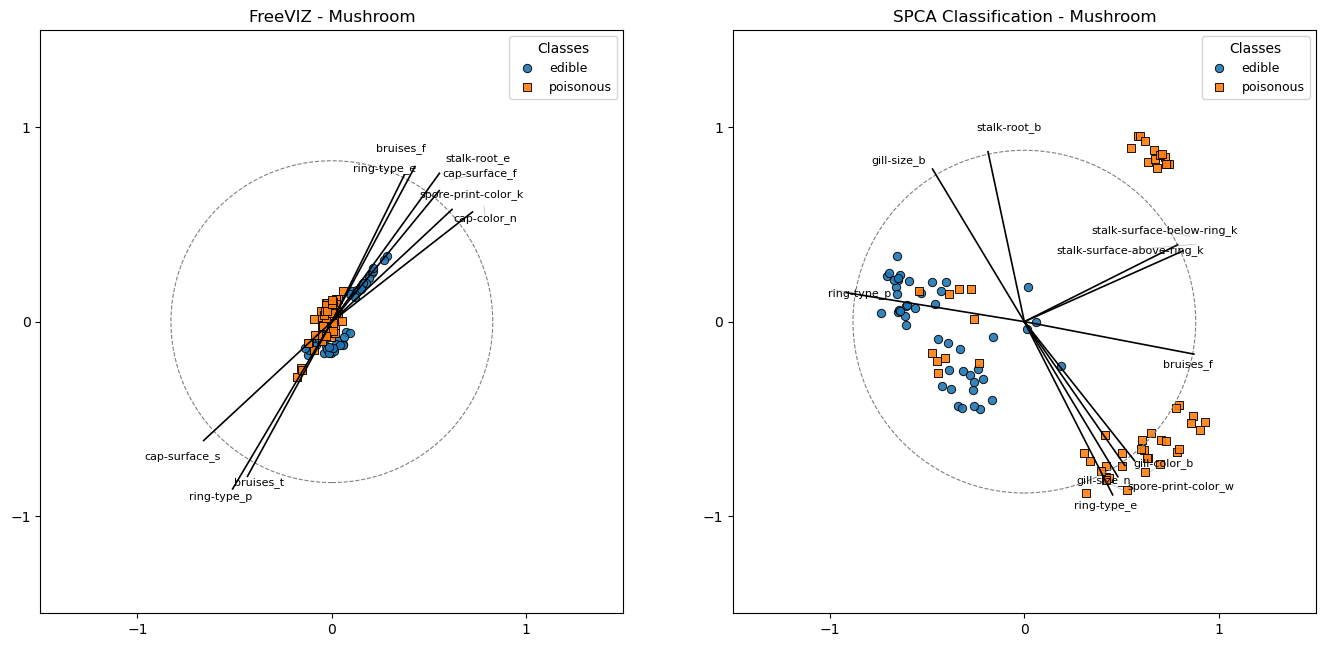

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeVIZ - Mushroom', ax=ax1, text_scale=1.08, top_n_loadings=10
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA Classification - Mushroom', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.show()

# The GLASS dataset

#### Data preparation

In [11]:
E_glass, C_glass, names_glass, feature_names_glass, class_names_glass = load_glass_data(device)
E_glass = scale_features(E_glass)

#### Train FreeVIZ

In [12]:
freeviz_glass = Freeviz(E_glass.shape[1]).to(device)
freeviz_glass.train(E_glass, C_glass)

P_glass = freeviz_glass(E_glass)
A_glass = freeviz_glass.A
P_glass_np = P_glass.detach().cpu().numpy()
C_glass_np = C_glass.detach().cpu().numpy()
A_glass_np = A_glass.detach().cpu().numpy()

step: 1 loss: 111225.421875
step: 2 loss: 274112.4375
step: 3 loss: 278572.84375
step: 4 loss: 195704.921875
step: 5 loss: 183798.640625
step: 6 loss: 171979.953125
step: 7 loss: 185509.84375
step: 8 loss: 181126.328125
step: 9 loss: 207720.0625
step: 10 loss: 289971.0
step: 11 loss: 165505.484375
step: 12 loss: 175972.609375
step: 13 loss: 202066.25
step: 14 loss: 234215.03125
step: 15 loss: 167031.09375
step: 16 loss: 261947.71875
step: 17 loss: 177976.046875
step: 18 loss: 170618.46875
step: 19 loss: 169554.21875
step: 20 loss: 166977.84375
step: 21 loss: 174888.34375
step: 22 loss: 194105.0625
step: 23 loss: 177922.609375
step: 24 loss: 263380.5
step: 25 loss: 199934.921875
step: 26 loss: 200293.4375
step: 27 loss: 200318.609375
step: 28 loss: 196761.421875
step: 29 loss: 191612.9375
step: 30 loss: 171550.140625
step: 31 loss: 214838.625
step: 32 loss: 167263.703125
step: 33 loss: 162236.984375
step: 34 loss: 160061.96875
step: 35 loss: 175281.078125
step: 36 loss: 190510.046875
st

#### Train SPCA Classification

In [13]:
model_glass = SPCA_Classification(input_dim=E_glass.shape[1], latent_dim=2, num_classes=len(class_names_glass), lr=0.05).to(device)
E_glass_centered = E_glass - E_glass.mean(dim=0)
model_glass.train(E_glass_centered, C_glass, lam=0.01, steps=1000, classifier_epochs=50)

L_glass = model_glass.L.detach().clone()
L_glass = L_glass - L_glass.mean(dim=0, keepdim=True)
loading_norms_glass = torch.norm(L_glass, dim=1)
L_glass = L_glass / loading_norms_glass.max()

Z_glass = E_glass_centered @ L_glass
z_max_glass = torch.abs(Z_glass).max()
Z_glass = Z_glass / z_max_glass

Z_glass_np = Z_glass.cpu().numpy()
C_glass_np_spca = C_glass.cpu().numpy()
L_glass_np = L_glass.cpu().numpy()

Step 0: loss = 1.9522, classifier loss = 1.7433
Step 10: loss = 1.6460, classifier loss = 1.4364
Step 20: loss = 1.5116, classifier loss = 1.3005
Step 30: loss = 1.4386, classifier loss = 1.2253
Step 40: loss = 1.3907, classifier loss = 1.1752
Step 50: loss = 1.3561, classifier loss = 1.1380
Step 60: loss = 1.3294, classifier loss = 1.1086
Step 70: loss = 1.3077, classifier loss = 1.0839
Step 80: loss = 1.2893, classifier loss = 1.0624
Step 90: loss = 1.2732, classifier loss = 1.0427
Step 100: loss = 1.2588, classifier loss = 1.0243
Step 110: loss = 1.2458, classifier loss = 1.0072
Step 120: loss = 1.2341, classifier loss = 0.9916
Step 130: loss = 1.2253, classifier loss = 0.9797
Step 140: loss = 1.2235, classifier loss = 0.9767
Step 150: loss = 1.2223, classifier loss = 0.9751
Step 160: loss = 1.2211, classifier loss = 0.9735
Step 170: loss = 1.2200, classifier loss = 0.9720
Step 180: loss = 1.2188, classifier loss = 0.9705
Step 190: loss = 1.2177, classifier loss = 0.9691
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


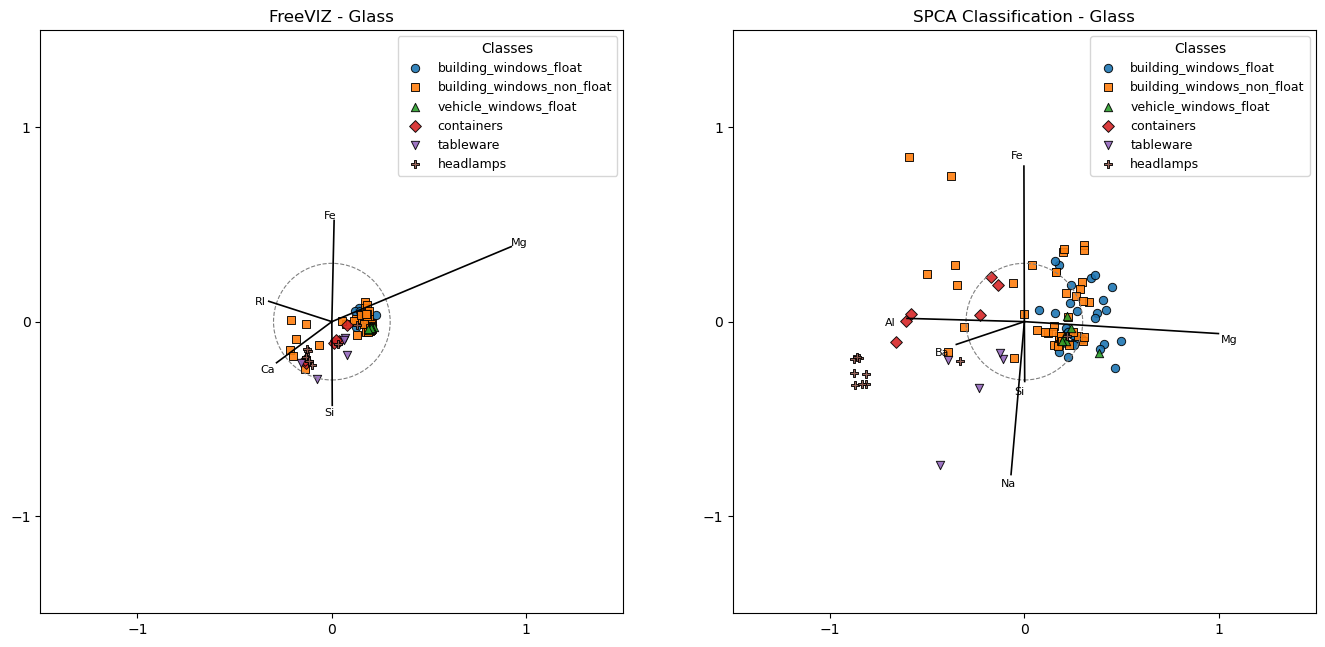

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_glass_np, vectors=A_glass_np, feature_names=feature_names_glass,
    class_codes=C_glass_np, class_names=class_names_glass,
    title='FreeVIZ - Glass', ax=ax1, text_scale=1.08, loading_cutoff=0.3
)

plot_projection(
    points=Z_glass_np, vectors=L_glass_np, feature_names=feature_names_glass,
    class_codes=C_glass_np_spca, class_names=class_names_glass,
    title='SPCA Classification - Glass', ax=ax2, text_scale=1.1, loading_cutoff=0.3
)

plt.tight_layout()
plt.show()

# The BREAST CANCER dataset

#### Data preparation

In [15]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
E_bc = scale_features(E_bc)

#### Train FreeVIZ

In [16]:
freeviz_bc = Freeviz(E_bc.shape[1]).to(device)
freeviz_bc.train(E_bc, C_bc)

P_bc = freeviz_bc(E_bc)
A_bc = freeviz_bc.A
P_bc_np = P_bc.detach().cpu().numpy()
C_bc_np = C_bc.detach().cpu().numpy()
A_bc_np = A_bc.detach().cpu().numpy()

step: 1 loss: 916478.6875
step: 2 loss: 1318479.875
step: 3 loss: 2445198.25
step: 4 loss: 1470992.125
step: 5 loss: 1671165.75
step: 6 loss: 1262246.875
step: 7 loss: 1176569.875
step: 8 loss: 1373258.375
step: 9 loss: 1220282.625
step: 10 loss: 1199090.375
step: 11 loss: 1153084.25
step: 12 loss: 1127827.875
step: 13 loss: 1180178.75
step: 14 loss: 1000219.3125
step: 15 loss: 936279.1875
step: 16 loss: 959431.9375
step: 17 loss: 1130947.375
step: 18 loss: 859861.625
step: 19 loss: 891931.625
step: 20 loss: 919600.625
step: 21 loss: 1145459.0
step: 22 loss: 914354.4375
step: 23 loss: 852858.0625
step: 24 loss: 891887.0625
step: 25 loss: 803532.25
step: 26 loss: 800408.75
step: 27 loss: 791662.1875
step: 28 loss: 781439.6875
step: 29 loss: 764647.25
step: 30 loss: 794763.1875
step: 31 loss: 748210.9375
step: 32 loss: 753332.75
step: 33 loss: 717765.25
step: 34 loss: 1268702.0
step: 35 loss: 1021424.0625
step: 36 loss: 1087573.375
step: 37 loss: 1059303.75
step: 38 loss: 952754.375
step

#### Train SPCA Classification

In [17]:
model_bc = SPCA_Classification(input_dim=E_bc.shape[1], latent_dim=2, num_classes=len(class_names_bc), lr=0.05).to(device)
E_bc_centered = E_bc - E_bc.mean(dim=0)
model_bc.train(E_bc_centered, C_bc, lam=0.01, steps=1000, classifier_epochs=50)

L_bc = model_bc.L.detach().clone()
L_bc = L_bc - L_bc.mean(dim=0, keepdim=True)
loading_norms_bc = torch.norm(L_bc, dim=1)
L_bc = L_bc / loading_norms_bc.max()

Z_bc = E_bc_centered @ L_bc
z_max_bc = torch.abs(Z_bc).max()
Z_bc = Z_bc / z_max_bc

Z_bc_np = Z_bc.cpu().numpy()
C_bc_np_spca = C_bc.cpu().numpy()
L_bc_np = L_bc.cpu().numpy()

Step 0: loss = 1.7047, classifier loss = 0.6555
Step 10: loss = 1.5121, classifier loss = 0.4624
Step 20: loss = 1.4146, classifier loss = 0.3647
Step 30: loss = 1.3531, classifier loss = 0.3031
Step 40: loss = 1.3113, classifier loss = 0.2612
Step 50: loss = 1.2812, classifier loss = 0.2309
Step 60: loss = 1.2586, classifier loss = 0.2081
Step 70: loss = 1.2410, classifier loss = 0.1903
Step 80: loss = 1.2270, classifier loss = 0.1761
Step 90: loss = 1.2156, classifier loss = 0.1646
Step 100: loss = 1.2134, classifier loss = 0.1623
Step 110: loss = 1.2122, classifier loss = 0.1612
Step 120: loss = 1.2111, classifier loss = 0.1600
Step 130: loss = 1.2100, classifier loss = 0.1589
Step 140: loss = 1.2089, classifier loss = 0.1578
Step 150: loss = 1.2078, classifier loss = 0.1567
Step 160: loss = 1.2068, classifier loss = 0.1556
Step 170: loss = 1.2058, classifier loss = 0.1546
Step 180: loss = 1.2048, classifier loss = 0.1536
Step 190: loss = 1.2038, classifier loss = 0.1526
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


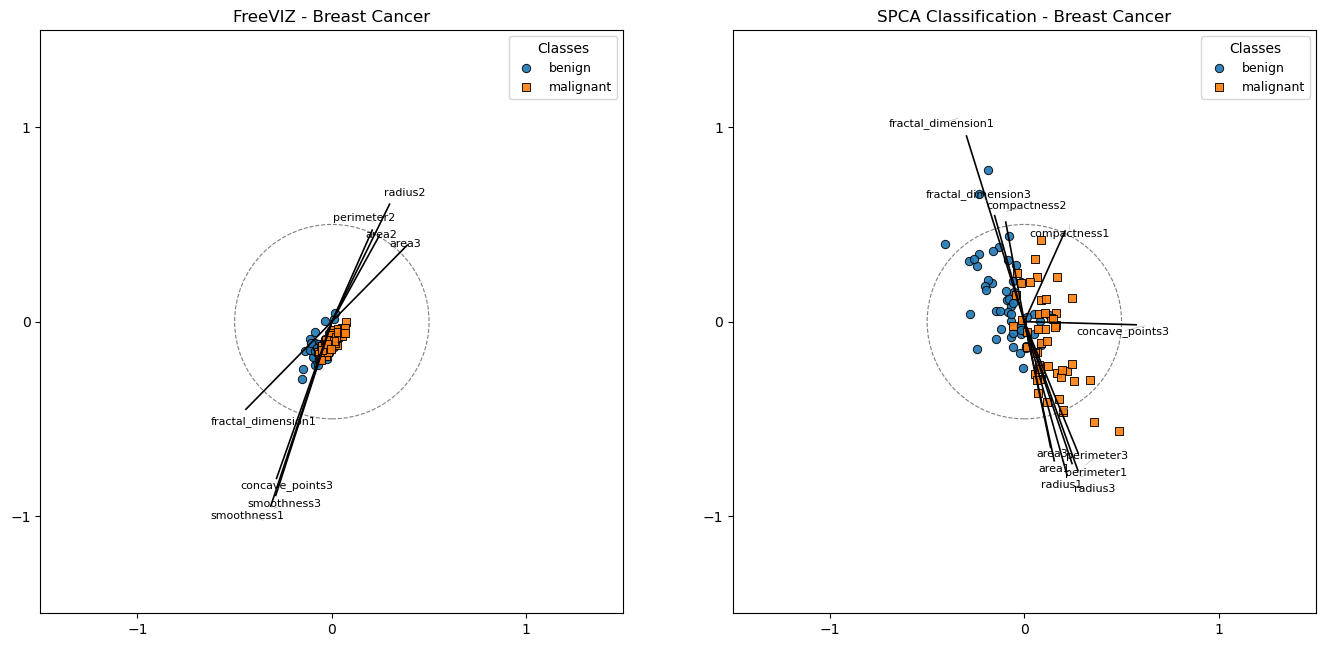

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_bc_np, vectors=A_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np, class_names=class_names_bc,
    title='FreeVIZ - Breast Cancer', ax=ax1, text_scale=1.08, loading_cutoff=0.5
)

plot_projection(
    points=Z_bc_np, vectors=L_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np_spca, class_names=class_names_bc,
    title='SPCA Classification - Breast Cancer', ax=ax2, text_scale=1.1, loading_cutoff=0.5
)

plt.tight_layout()
plt.show()